# **Laboratorio 1 - Análisis Exploratorio de Datos**

In [34]:
import pandas as pd #Para manejar los datos con tablas
import seaborn as sns #Para realizar gráficas estadisticas
import matplotlib.pyplot as plt #Graficos básicos
ur = 'https://raw.githubusercontent.com/ivanordenes/analisis-datos/refs/heads/main/Life%20Expectancy%20Data.csv' #URL dataset seleccionado

df=pd.read_csv(ur) #Lee archivo .csv desde la URL y lo guarda
print(df.shape) #Imprimir forma del dataframe, indica qué tamaño tiene (filas,columnas)
print(df) #Imprimir todo el dataframe (primeras 5 filas y últimas 5 filas)

(2938, 22)
          Country  Year      Status  Life expectancy   Adult Mortality  \
0     Afghanistan  2015  Developing              65.0            263.0   
1     Afghanistan  2014  Developing              59.9            271.0   
2     Afghanistan  2013  Developing              59.9            268.0   
3     Afghanistan  2012  Developing              59.5            272.0   
4     Afghanistan  2011  Developing              59.2            275.0   
...           ...   ...         ...               ...              ...   
2933     Zimbabwe  2004  Developing              44.3            723.0   
2934     Zimbabwe  2003  Developing              44.5            715.0   
2935     Zimbabwe  2002  Developing              44.8             73.0   
2936     Zimbabwe  2001  Developing              45.3            686.0   
2937     Zimbabwe  2000  Developing              46.0            665.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
0                62  

## **1. Conjunto de datos**

El conjunto de datos seleccionado se centra en la expectativa de vida para 193 países del mundo durante un período comprendido entre los años 2000 y 2015. Además de considerar variables demográficas, de ingreso y de mortalidad, añade un enfoque a factores como la inmunización ante enfermedades y el índice de desarrollo humano, por el fuerte avance que ha tenido esta primera. De esta manera, cuenta con un total de 22 columnas (20 sujetas a análisis) y 2938 filas.
En cuento al origen de los datos, las variables correspondientes a salud se obtuvieron del sitio web del repositorio de datos del Observatorio Global de Salud (OGS), de la Organización Mundial de Salud (OMS); mientras que las económicas provienen del sitio web de las Naciones Unidas. El archivo es una fusión de los datos para cada año individualmente.

La motivación de estudio del dataset presentado nace desde la curiosidad de entender si hay factores que tengan una verdadera incidencia en cuánto durará la vida de una persona, y si puede ser afectado por sus hábitos o la mera posibilidad/coindicencia de nacer en un país u otro; a la educación que se puede acceder en él, la exposición o inmunización contra enfermedades e incluso los recursos monetarios destinados a estos dos primeros.

##2. Variables

####1. Country: Categórica Nominal
País del que fue sacada la muestra
####2. Year: Discreta
Año de la muestra
####3. Status: Categórica Ordinal
Indica si el país es Desarrollado o está En Desarrollo
####4. Life expectancy: Continua
Expectativa de vida en años
####5. Adult Mortality: Discreta
Mortalidad de los adultos cada mil habitantes (entre 15 y 60 años)
####6. Infant deaths: Discreta
Fallecimientos de infantes cada mil personas
####7. Alcohol: Continua
Litros de alcohol (puro) que consume una persona de +15 años en promedio
####8. Percentage Expediture: Continua
Gasto en salud per cápita como porcentaje del PIB (Producto Interno Bruto)
####9. Hepatitis B: Continua
Proporción de menores de 1 año que completaron su vacunación contra la Hepatitis B
####10. Measles: Discreta
Número de casos de Sarampión por cada mil habitantes
####11. BMI: Continua
Índice de masa corporal
####12. Under-Five_Deaths: Discreta
Fallecimientos por cada 1000 nacidos vivos menores de 5 años
####13. Polio: Discreta
Porcentaje de menores de 1 año vacunados contra el polio
####14. Total expenditure: Discreta
Porcentaje del gasto total destinado a salud por parte de los gobiernos
####15. Diphtheria: Continua
Porcentaje de menores de 1 año con su inmunización completa contra la Difteria, Tétanos y Pertussis
####16. HIV/AIDS: Continua
Porcentaje de menores de 4 años que fallecen por VIH
####17. GDP: Continua
PIB per cápita en dólares
####18. Population: Discreta
Población del país
####19. Thinness 1-19 years: Continua
Porcentaje de personas menores de 19 años que están por debajo del peso saludable por edad y estatura
####20. Thinness 5-9 years: Continua
Porcentaje de personas menores de 9 años y mayores de 5 que están por debajo del peso saludable por edad y estatura
####21. Income composition of resources: Continua
Índice de Desarrollo Humano (IDH); valor entre 0 y 1
####22. Schooling: Continua
Número de años de educación promedio





##**Mapa de calor**
Este mapa de calor tendrá como objetivo orientarnos sobre dónde están las principales relaciones entre las columnas, y poder comprender de mejor manera el dataset a grandes rasgos.

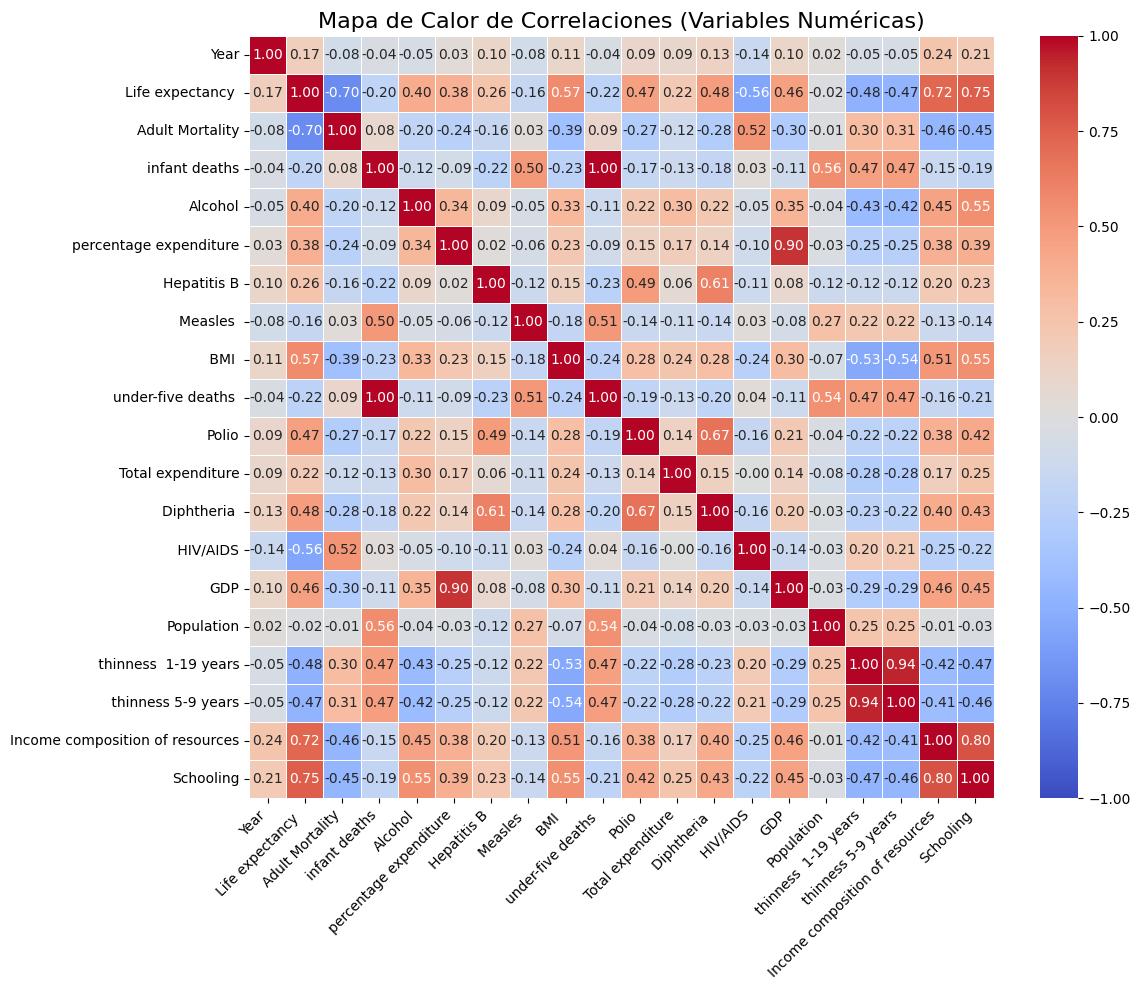

In [35]:
matriz_corr = df.corr(numeric_only=True) #Calcula la matriz de correlación con variables numéricas
plt.figure(figsize=(12, 10)) #Define el tamaño del gráfico
#Dibuja el mapa de calor a partir de la matriz de correlación
sns.heatmap(matriz_corr,
            annot=True, #Incluimos los valores de correlación
            cmap='coolwarm', #colores fríos y cálidos
            fmt=".2f", #2 decimales
            linewidths=0.5,
            vmin=-1, vmax=1) #valores entre -1 y 1
plt.title('Mapa de Calor de Correlaciones (Variables Numéricas)', fontsize=16) #Título gráfico
plt.xticks(rotation=45, ha='right') #Rotación nombres de las columnas de un eje a otro
plt.tight_layout() #Ajuste de tamaño
plt.show() #Imprime el gráfico

A través de esto, se puede notar que las variables con más correlación con la expectativa de vida, que es el camino por el que irá nuestro trabajo (y por el cual el autor reunió las filas para crear el dataset), son:

'Income composition of resources'

'Schooling'

'thinness 5-9 years'

'BMI'


##**Principales cálculos estadísticos de las variables más relacionadas**
Acotando un poco las variables de interés, calculamos las principales medidas de tendencia y dispersión.

Medidas de tendencia central:
- Media
- Mediana
- Moda

Medidas de dispersión:
- Desviación Estándar
- Rango
- Varianza

In [36]:
columnas_analizar = [ 'Life expectancy ', ' thinness 5-9 years', 'Schooling', 'Income composition of resources',  ' BMI ']
print(df[columnas_analizar].describe()) #cuenta la cantidad de datos, la media, desviación estándar, valor mínimo, primer cuartil, segundo cuartil (mediana), tercer cuartil y valor máximo

modas = df[columnas_analizar].mode() #calculamos la moda para las columnas de interés
print('\nMODAS:\n',modas)

minimos = df[columnas_analizar].min()
maximos = df[columnas_analizar].max()
print(f'\nRANGOS:')
i = 0
while(i <5):
  print(columnas_analizar[i],': ',maximos[i]-minimos[i])
  i += 1

varianza = df[columnas_analizar].var()
print('\nVARIANZAS:\n ',varianza)

       Life expectancy    thinness 5-9 years    Schooling  \
count       2928.000000          2904.000000  2775.000000   
mean          69.224932             4.870317    11.992793   
std            9.523867             4.508882     3.358920   
min           36.300000             0.100000     0.000000   
25%           63.100000             1.500000    10.100000   
50%           72.100000             3.300000    12.300000   
75%           75.700000             7.200000    14.300000   
max           89.000000            28.600000    20.700000   

       Income composition of resources         BMI   
count                      2771.000000  2904.000000  
mean                          0.627551    38.321247  
std                           0.210904    20.044034  
min                           0.000000     1.000000  
25%                           0.493000    19.300000  
50%                           0.677000    43.500000  
75%                           0.779000    56.200000  
max               

/tmp/ipykernel_1085/2187176347.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(columnas_analizar[i],': ',maximos[i]-minimos[i])


En general, se puede ver que las columnas de interés tienen una cantidad de datos casi completa: entre las 2938 muestras, estas tienen casi todos los valores, por lo que tenemos muchos datos utilizables. También se puede ver cómo las medianas y los promedios no están tan alejados, de modo que nos aseguramos de que no cuentan con tantos datos atípicos que hagan que se diferencien de gran manera; deberían estar bien concentrados. Igualmente, se puede ver mucha varianza en algunos datos, lo que es esperable por la medida de cada uno.
Indiferentemente, nuestras variables de interés, sí tienen una buena calidad de muestras que pueden ser relacionadas de forma satisfactoria.

## **3. Limpieza de Datos**

Haciendo un breve análisis de los datos, nos percatamos de dos problemas a solucionar:
### 1. Datos faltantes
Notamos una cantidad notable de datos nulos (NaN), de modo que verificamos qué porcentaje faltaba realmente para cada columna, obteniendo el siguiente resultado:

In [37]:
porcentaje_de_datos_nulos = df.isnull().sum()*(100/2938) #Contamos el número de ocurrencias nulas del total de las 2938 y multiplicándolas por 100 para tener el porcentaje de valores nulos por columna
print(porcentaje_de_datos_nulos)


Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
 BMI                                1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
 HIV/AIDS                           0.000000
GDP                                15.248468
Population                         22.191967
 thinness  1-19 years               1.157250
 thinness 5-9 years                 1.157250
Income composition of resources     5.684139
Schooling                           5.547992
dtype: flo

  Las columnas más significativos fueron Población (Population), con aproximadamente un 22% de datos faltantes, Hepatitis B (aproximadamente 19%) y GDP (aproximadamente 15%).

### 2. Datos poblacionales erróneos
Como adición al primer problema, en la columna de población habían países donde los valores podían llegar a ser extremadamente menores al resto, como lo es por ejemplo Albania:

In [38]:
print(df.loc[df['Country'] == 'Albania', ['Country', 'Year','Population']]) #Localizamos en la columna 'Country' todas las filas con el valor 'Albania'; para aquellas imprimimos los datos 'Country', 'Year' y 'Population'

    Country  Year  Population
16  Albania  2015     28873.0
17  Albania  2014    288914.0
18  Albania  2013    289592.0
19  Albania  2012      2941.0
20  Albania  2011    295195.0
21  Albania  2010    291321.0
22  Albania  2009   2927519.0
23  Albania  2008   2947314.0
24  Albania  2007     29717.0
25  Albania  2006   2992547.0
26  Albania  2005    311487.0
27  Albania  2004    326939.0
28  Albania  2003    339616.0
29  Albania  2002      3511.0
30  Albania  2001     36173.0
31  Albania  2000     38927.0


En 2011 cuenta con 295195 habitantes, pero al año siguiente, el número se reduce a 2941, para volver a aumentar a 289592 el 2013. El autor del dataset no menciona el origen específico de los datos poblacionales, pero estos provienen junto a los obtenidos de la OMS.

Según la página [Datosmacro.com](https://datosmacro.expansion.com/demografia/poblacion/albania), en 2011, Albania contaba con 2903008 habitantes, de modo que el dato con el que contamos se encuentra en un orden de magnitud distinto; así mismo sucede con 2012, donde era 2897770.
Entonces, la población no solo no fue registrada en el orden de los millones (o cientos de millones, según el caso), sino que el orden empleado para cada país y cada año parece ser distinto y no estar estandarizado por ninguna categoría: no podemos identificar un estándar ni para los países como para los años.

##**Gráfico IDH antes de limpieza**

Antes de aplicar la solución, se muestra un gráfico de ejemplo de la relación entre el Índice de Desarrollo Humano y la Expectativa de vida, para poder entender el efecto del tratamiento de los datos:

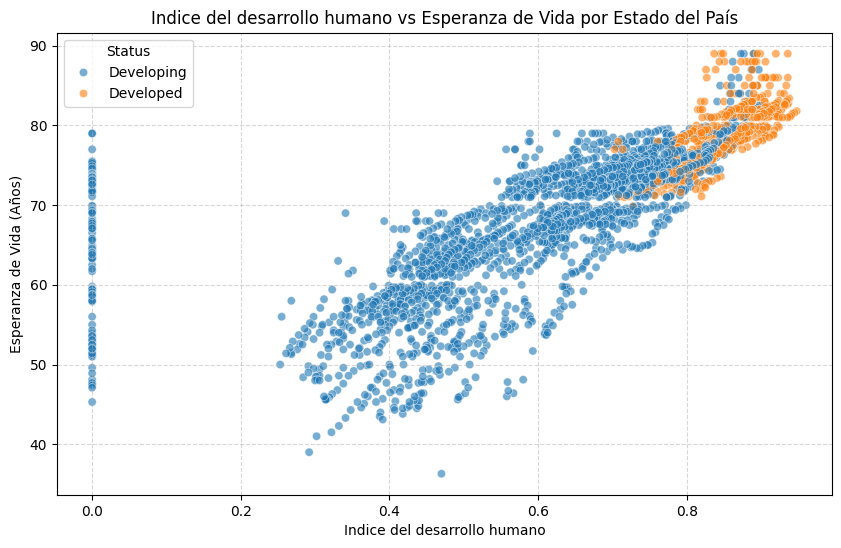

In [39]:
plt.figure(figsize=(10, 6)) #Crea figura de tamaño 10x6

#Crear grafico de dispersión
sns.scatterplot(data=df, x='Income composition of resources', y='Life expectancy ', hue='Status', alpha=0.6) #Hue separa los puntos según la variable 'Status'
plt.title('Indice del desarrollo humano vs Esperanza de Vida por Estado del País') #Título
plt.xlabel('Indice del desarrollo humano') #Etiqueta de eje x
plt.ylabel('Esperanza de Vida (Años)') #Etiqueta eje y
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() #Imprime gráfico

### 3. Soluciones
La solución fue la misma para los dos problemas; asignar a los valores faltantes la mediana del resto de la columna (los datos que sí habían). No quisimos eliminar las filas ya que perderíamos un alto porcentaje de información.
En cuanto al tema de la población, llegamos al concenso de que no sería de utilidad analítica, y sólo preservaremos los valores para contar con los datos del resto de la fila (las otras columnas).

El proceso fue así:

In [40]:
df_copia = pd.DataFrame(df) #Copia dataframe
df = df_copia.fillna(df.median(numeric_only=True)) #Rellena los valores nulos con la mediana de cada columna (fillna reemplaza valores vacios).
filas_con_datos_nulos_ahora = df[df.isnull().any(axis=1)] #Busca filas que tenga valores nulos tras llenar con la mediana
print(df) #Imprime el dataframe con valores rellenados

          Country  Year      Status  Life expectancy   Adult Mortality  \
0     Afghanistan  2015  Developing              65.0            263.0   
1     Afghanistan  2014  Developing              59.9            271.0   
2     Afghanistan  2013  Developing              59.9            268.0   
3     Afghanistan  2012  Developing              59.5            272.0   
4     Afghanistan  2011  Developing              59.2            275.0   
...           ...   ...         ...               ...              ...   
2933     Zimbabwe  2004  Developing              44.3            723.0   
2934     Zimbabwe  2003  Developing              44.5            715.0   
2935     Zimbabwe  2002  Developing              44.8             73.0   
2936     Zimbabwe  2001  Developing              45.3            686.0   
2937     Zimbabwe  2000  Developing              46.0            665.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   \
0                62     0.01    

Si verificamos, vamos a ver que tras hacer los cambios, hay 0 columnas con valores nulos:

In [41]:
total_nulos = df.isnull().sum().sum() #Contador de valores nulos en dataframe
print(total_nulos) #Imprime total de valores nulos


0


### Datos atípicos/outliers
Para identificar la presencia de valores atípicos en el conjunto de datos, realizamos el siguiente proceso con 5 variables de nuestro interés:

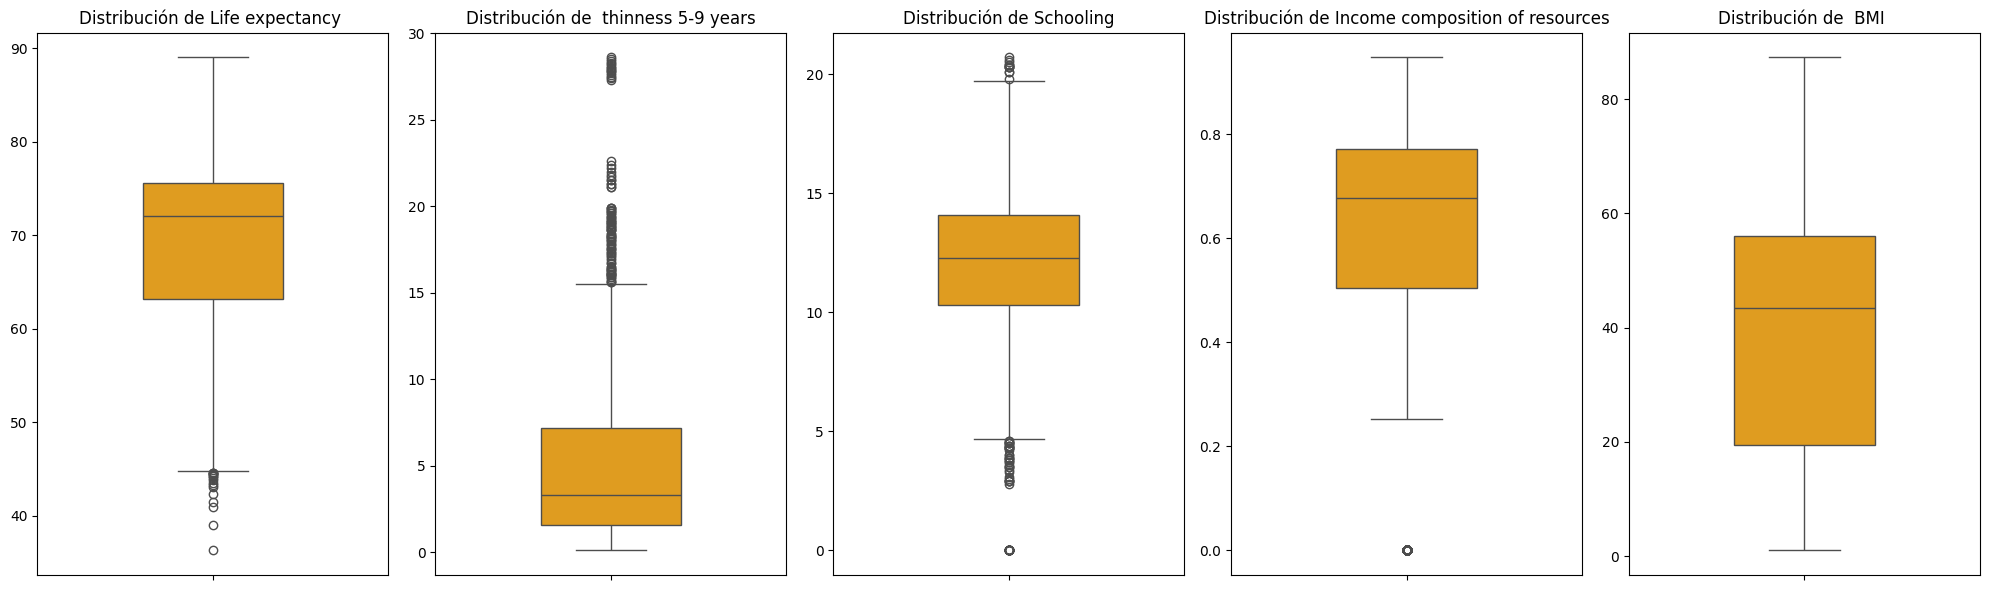

In [42]:
columnas_analizar = [ 'Life expectancy ', ' thinness 5-9 years', 'Schooling', 'Income composition of resources',  ' BMI ']
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6)) #Se crea la figura que se repetirá y una matriz, con tamaño, filas y columnas para desplegar los gráficos
for i, colum in enumerate(columnas_analizar): #Itera sobre las filas y las columnas, para analizarlas
    sns.boxplot(y=df[colum], ax=axes[i], color='Orange', width=0.4) #Creamos el diagrama con los datos en una casilla i
    axes[i].set_title(f'Distribución de {colum}', fontsize=12) #Se coloca el título de distribución de la columna para la cual se creó el gráfico
    axes[i].set_ylabel('')
plt.tight_layout() #Corrección visual de los títulos
plt.show()

A nuestras variables más relacionadas, y de interés, eliminaremos los datos atípicos mostrados en los diagramas de caja para tenerlos más concentrados y que se puedan extrapolar de mejor manera, ya que al ser un estudio a gran escala, no podemos ensuciar los datos con aquellos que sean muy aislados y que tengan muy poca frecuencia. Esto se hará considerando los rangos intercuartiles, para tener una mejor precisión al sacar los datos:

In [43]:
df_respaldo= df.copy()
for columna in columnas_analizar:#Se recorre cada columna que se quiere limpiar
  q1= df[columna].quantile(0.25) #Parte baja de los datos (Datos más pequeños), primer cuartil
  q3= df[columna].quantile(0.75) #Parte alta de los datos (Datos más grandes), tercer cuartil
  inter= q3 - q1 #Rango entre los valores (rango intercuartil)
  limite_inf= q1 - (inter*1.5) #Se definen los límites inferior y superior
  limite_sup= q3 + (inter*1.5)

  df= df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)] #Se seleccionan sólo datos dentro del rango
print(len(df)) #Cuántos datos quedan tras la eliminación
print(len(df_respaldo)) #Cuántos datos teníamos antes

2650
2938


### Nueva repartición de datos
Ahora, con la limpieza de datos atípicos, vamos a generar nuevamente los gráficos de caja para comparar la repartición de los datos:

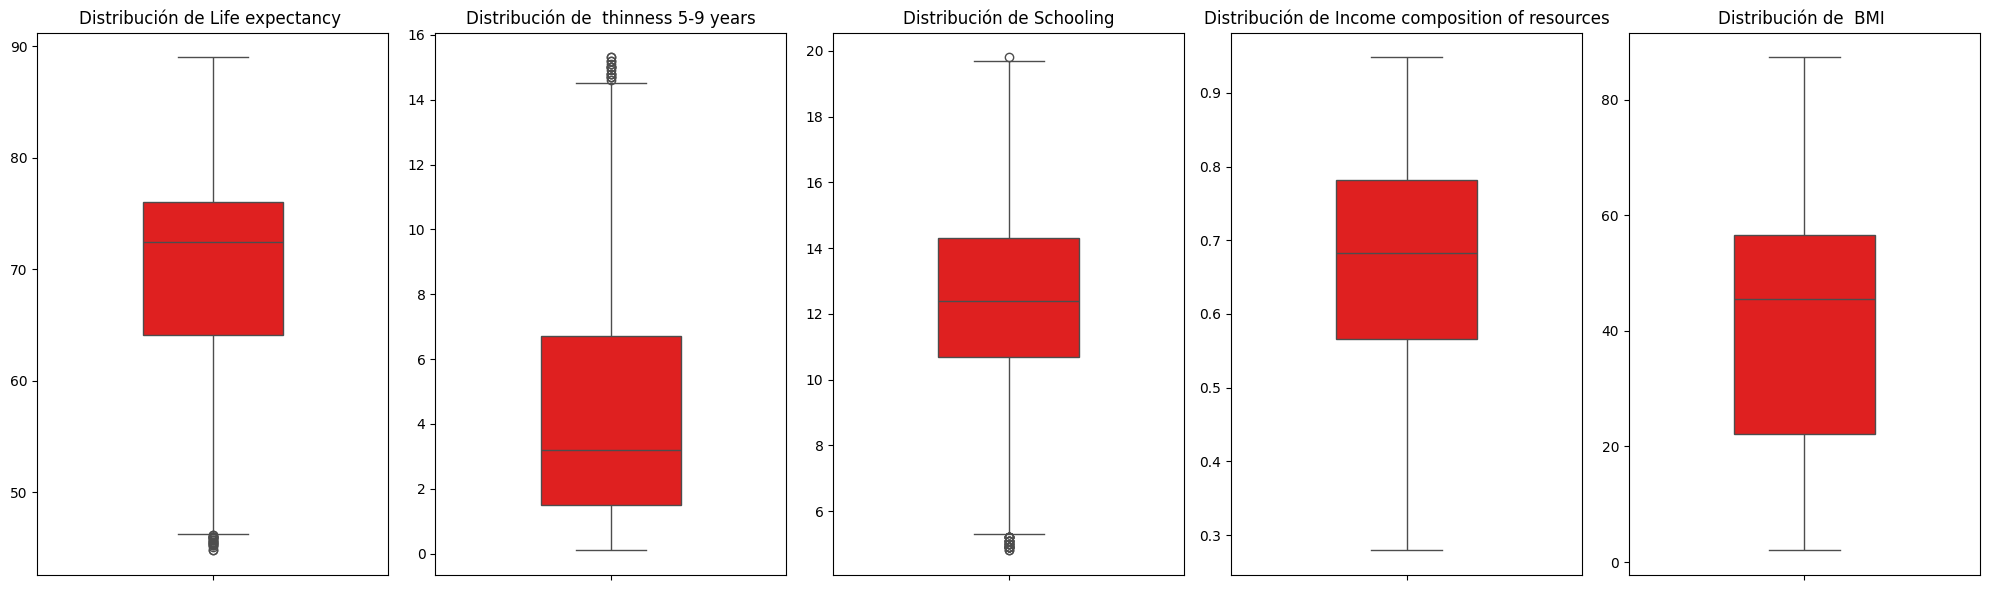

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6)) #Se crea la figura con varios espacios para los gráficos
for i, colum in enumerate(columnas_analizar): #Se recorre cada columna
    sns.boxplot(y=df[colum], ax=axes[i], color='red', width=0.4) #Se hace el grafico de la columna
    axes[i].set_title(f'Distribución de {colum}', fontsize=12) #Se pone titulo
    axes[i].set_ylabel('') #No muestra nombre en el eje y
plt.tight_layout() #Ajuste de espacios, para el orden
plt.show() #Imprime gráficos

##**Gráfico IDH con datos limpios**

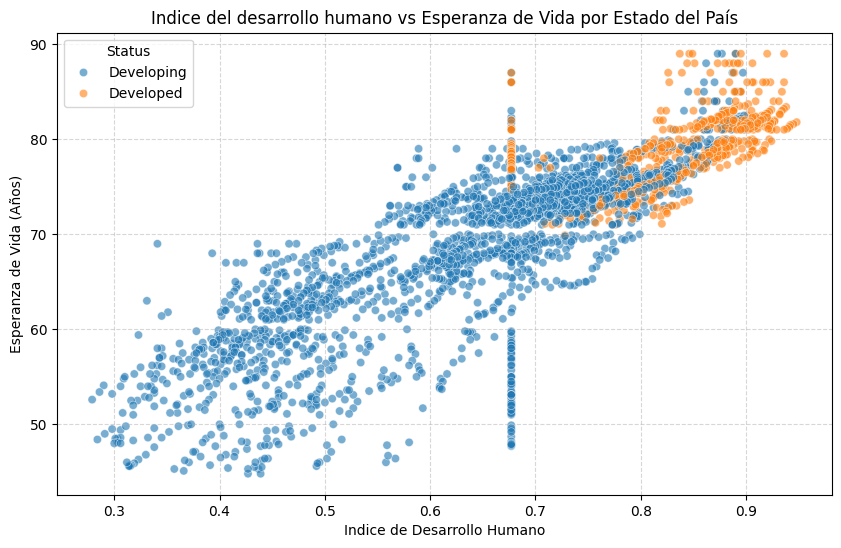

In [45]:
plt.figure(figsize=(10, 6)) #Crea figura de tamaño 10x6

#Crear grafico de dispersión
sns.scatterplot(data=df, x= 'Income composition of resources', y='Life expectancy ', hue='Status', alpha=0.6) #hue clasifica los valores por la variable 'Status'
plt.title('Indice del desarrollo humano vs Esperanza de Vida por Estado del País') #Título
plt.xlabel('Indice de Desarrollo Humano') #Etiqueta de eje x
plt.ylabel('Esperanza de Vida (Años)') #Etiqueta eje y
plt.grid(True, linestyle='--', alpha=0.5)

plt.show() #Imprime gráfico

  ## **4. Selección de variables**

Como el dataset gira en torno a la expectativa de vida, siempre tuvimos en mente estudiarla y elegir el resto de variables para que 'giren en torno a ella', de cierta forma (podríamos haberla no incluido y escoger otras igualmente, sólo fue interés personal). Así, el mapa de calor sirvió como herramienta para identificar las que más parecían incidir, reduciendo las opciones a 5.
Con la identificación y eliminación de outliers, usando los diagramas de caja, logramos entender cuales de aquellas variables estaban más dispersas, y cuales parecían tener un comportamiento más uniforme y controlado. En vista de aquello, las variables seleccionadas fueron:

### Principales
- Esperanza de Vida ('Life Expectancy')
- Índice de Desarrollo Humano ('Income Composition of Resources'): Es la de mayor impacto entre todas.

### Secundarias
- Años promedio de Escolaridad ('Schooling'): Factor social/económico.
- Delgadez ante edad y estatura ('thinness 5-9 years'): Factor de salud.

Nuestras intenciones al hacer estas elecciones es poder contrastar los aspectos sociales y de comportamiento contra aquellos netamente biológicos y científicos: extraer una variable de cada categoría para analizar de una manera más focalizada.

## **5. Hipótesis/Pregunta de Investigación**
 ¿En los países con un IDH mayor al promedio, cuánto afectan los años de escolaridad a sus expectativas de vida?

## **Conclusión**


Durante el análisis del dataset, se observó una gran cantidad de datos faltantes, incluyendo casos en los que algunos países no contaban con registros. Además, se detectaron errores en los datos, especialmente en la variable de población, donde en un intervalo de un año podían presentarse variaciones poco realistas, como disminuciones de más de dos órdenes de magnitud, lo que evidenciaba una falta de consistencia.

En un inicio, se consideró utilizar la población como variable de análisis, por lo que se intentó corregir estos problemas. Una de las opciones evaluadas fue eliminar los países con datos inconsistentes; sin embargo, esto implicaba perder información relevante de otras variables, por lo que se descartó esta alternativa.

Como solución, se optó por reemplazar los valores faltantes o erróneos por la mediana del conjunto de datos. No obstante, debido a la alta cantidad de inconsistencias detectadas, se concluyó que la variable de población no proporcionaba información lo suficientemente confiable, por lo que finalmente se decidió no utilizarla en el análisis.

Finalmente, se hizo una limpieza de datos más a fondo con los datos atípicos en las variables de interés, eliminando todos aquellos fuera del rango intercuartílico para tener un volumen de datos con una relación aún mayor y más clara (procurando no eliminar tantas muestras) y poder seguir teniendo una buena fiabilidad en estas. Con lo que se pudo dar con una buena pregunta, que pueda ser analizada mediante los datos que tenemos en nuestro poder y con relación a nuestras variables principales.
